# Evaluation: Basic RAG vs advanced agentic RAG (OpenAI)

- **Questions:** first 20 bullet items in `test_questions.md` (lines starting with `*`).
- **Basic RAG:** `RagRetriever` + `answer_with_rag` (`src.rag`), generator `gpt-4o-mini`.
- **Advanced RAG:** `AdvancedRegulationAssistant` with OpenAI synthesizer (`src.advanced_rag`).
- **Judge:** `gpt-4o-mini` compares the two answers per question (JSON: preference, scores, rationale).

Requires `.env` with `OPENAI_API_KEY`, Pinecone settings, and ingested `chunks/` for retrieval.

## Advanced multi-agent RAG (LangGraph `StateGraph`-style)

```mermaid
flowchart TD
  START([START]) --> resolve_context[resolve_context]

  resolve_context --> plan[plan]

  plan --> retrieve_semantic[retrieve_semantic]
  plan --> retrieve_exact[retrieve_exact]

  retrieve_semantic --> merge_evidence[merge_evidence]
  retrieve_exact --> merge_evidence

  merge_evidence --> grade_documents[grade_documents]

  grade_documents -->|relevant| generate[generate]
  grade_documents -->|not_relevant| transform_query[transform_query]

  transform_query --> retrieve_semantic

  generate --> grade_generation[grade_generation_v_documents_and_question]

  grade_generation -->|useful| END([END])
  grade_generation -->|not_supported| generate
  grade_generation -->|not_useful| transform_query
```

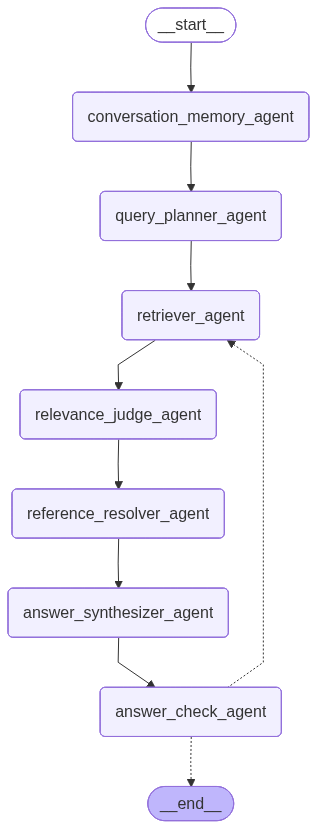

[ok] wrote advanced_rag_actual_langgraph.png


In [6]:
# LangGraph visualization: your *actual* advanced_rag graph (PNG)
# Mirrors `src/advanced_rag/graph.py` (nodes + edges + conditional routing)

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

from src.advanced_rag.nodes import (
    answer_check_node,
    answer_synthesizer_node,
    conversation_memory_node,
    query_planner_node,
    reference_resolver_node,
    relevance_judge_node,
    retriever_node,
)
from src.advanced_rag.state import AdvancedRagState

try:
    from langchain_core.runnables.graph import MermaidDrawMethod
except Exception:  # pragma: no cover
    MermaidDrawMethod = None  # type: ignore


# NOTE: These are placeholders so we can *draw* the graph without running it.
# The lambdas capture them but nothing is executed during rendering.
client = object()
retriever = object()
model = "gpt-4o-mini"
TOP_K = 8


graph = StateGraph(AdvancedRagState)

graph.add_node(
    "conversation_memory_agent",
    lambda s: conversation_memory_node(s, client=client, model=model),
)

graph.add_node(
    "query_planner_agent",
    lambda s: query_planner_node(s, client=client, model=model),
)

graph.add_node(
    "retriever_agent",
    lambda s: retriever_node(s, retriever=retriever, top_k=TOP_K),
)

graph.add_node(
    "relevance_judge_agent",
    lambda s: relevance_judge_node(s, client=client, model=model),
)

graph.add_node(
    "reference_resolver_agent",
    lambda s: reference_resolver_node(s, client=client, model=model, retriever=retriever),
)

synth_model = model

graph.add_node(
    "answer_synthesizer_agent",
    lambda s: answer_synthesizer_node(
        s,
        client=client,
        openai_model=synth_model,
    ),
)

graph.add_node(
    "answer_check_agent",
    lambda s: answer_check_node(s, client=client, model=model),
)

# Edges (exact order from `src/advanced_rag/graph.py`)

graph.add_edge(START, "conversation_memory_agent")

graph.add_edge("conversation_memory_agent", "query_planner_agent")

graph.add_edge("query_planner_agent", "retriever_agent")

graph.add_edge("retriever_agent", "relevance_judge_agent")

graph.add_edge("relevance_judge_agent", "reference_resolver_agent")

graph.add_edge("reference_resolver_agent", "answer_synthesizer_agent")

graph.add_edge("answer_synthesizer_agent", "answer_check_agent")


def _route_after_check(state: AdvancedRagState) -> str:
    if state.get("answer_supported", False):
        return END
    if state.get("retry_count", 0) >= 1:
        return END
    return "retriever_agent"


graph.add_conditional_edges(
    "answer_check_agent",
    _route_after_check,
    {
        END: END,
        "retriever_agent": "retriever_agent",
    },
)

app = graph.compile()

# Render PNG in notebook (and save to disk)
kwargs = {}
if MermaidDrawMethod is not None:
    kwargs["draw_method"] = MermaidDrawMethod.API

png_bytes = app.get_graph().draw_mermaid_png(**kwargs)

out_path = "advanced_rag_actual_langgraph.png"
with open(out_path, "wb") as f:
    f.write(png_bytes)

display(Image(png_bytes))
print(f"[ok] wrote {out_path}")


In [ ]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI

from src.advanced_rag import AdvancedRegulationAssistant
from src.rag.answer import answer_with_rag, build_context
from src.rag.retriever import RagRetriever

load_dotenv()

REPO = Path.cwd()
TEST_QUESTIONS_PATH = REPO / "test_questions.md"
N_QUESTIONS = 20
TOP_K = 5
GEN_MODEL = "gpt-4o-mini"
JUDGE_MODEL = "gpt-4o-mini"
MAX_CONTEXT_CHARS = 12000


def load_bullet_questions(md_path: Path, limit: int) -> list[str]:
    """First `limit` lines that look like markdown bullets: '* ...'"""
    text = md_path.read_text(encoding="utf-8")
    out: list[str] = []
    for line in text.splitlines():
        m = re.match(r"^\*\s+(.+?)\s*$", line.strip())
        if m:
            out.append(m.group(1).strip())
            if len(out) >= limit:
                break
    return out


EVAL_QUESTIONS = load_bullet_questions(TEST_QUESTIONS_PATH, N_QUESTIONS)
assert len(EVAL_QUESTIONS) == N_QUESTIONS, (
    f"Expected {N_QUESTIONS} bullet questions in {TEST_QUESTIONS_PATH}, got {len(EVAL_QUESTIONS)}"
)
for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"{i:2}. {q}")

/Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 1. What is the scope of the Power Unit Financial Regulations?
 2. What are the objectives of the Power Unit Financial Regulations?
 3. Who interprets and applies these regulations?
 4. When do these regulations come into force?
 5. What must a Power Unit Manufacturer do to demonstrate compliance with the Power Unit Cost Cap?
 6. What is the Power Unit Cost Cap for the N-3, N-2, and N-1 reporting periods?
 7. What is the Power Unit Cost Cap in a manufacturer’s inaugural season?
 8. What is a Reporting Group?
 9. What happens if a manufacturer has incurred less than 95% of Power Unit Activity costs itself?
10. What costs are excluded under Article E3?
11. Are marketing activities included in Relevant Costs?
12. Are finance costs excluded from Relevant Costs?
13. Are corporate income taxes excluded?
14. Are employee bonus costs fully excluded, or is there a cap?
15. Are health and safety costs excluded?
16. Are transportation costs excluded?
17. Are maternity and paternity leave costs ex

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY (e.g. in .env)")

INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "regs-2026-bgebased")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "regulations-2026")
PINECONE_HOST = os.getenv("PINECONE_HOST")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

retriever = RagRetriever(
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
    chunks_root="chunks",
)

assistant = AdvancedRegulationAssistant(
    llm_model=GEN_MODEL,
    answer_synthesizer_backend="openai",
    answer_synthesizer_openai_model=GEN_MODEL,
    top_k=TOP_K,
    chunks_root="chunks",
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
)

print(f"index={INDEX_NAME} namespace={NAMESPACE} gen={GEN_MODEL} judge={JUDGE_MODEL}")

index=regs-2026-bgebased namespace=regulations-2026 gen=gpt-4o-mini judge=gpt-4o-mini


In [3]:
def run_basic_rag(question: str) -> str:
    hits = retriever.retrieve(question, top_k=TOP_K)
    ctx = build_context(hits)
    if not ctx.strip():
        return "(no retrieval context)"
    return answer_with_rag(
        query=question,
        context=ctx,
        model=GEN_MODEL,
        client=client,
    )


def run_advanced_rag(question: str, idx: int) -> str:
    # Fresh session per question so memory does not carry across the eval set
    r = assistant.ask(question, session_id=f"eval-advanced-{idx}")
    return (r.answer or "").strip()


JUDGE_SYSTEM = """You are an expert evaluator for F1 Power Unit Financial Regulations Q&A.
You compare two answers to the same user question.
- Answer A was produced by **basic RAG**: retrieve chunks, then one LLM call over that context.
- Answer B was produced by **advanced agentic RAG**: multi-agent pipeline (planning, retrieval, judging, synthesis) with OpenAI.

Evaluate grounding (use of regulation concepts, avoiding obvious hallucination), correctness, and whether the answer addresses what was asked.
Return **only** a JSON object with exactly these keys:
- "preferred": one of "A", "B", "tie" (which answer is better overall; "tie" if similar quality)
- "base_rag_score": integer 1-5 (quality of Answer A)
- "advanced_rag_score": integer 1-5 (quality of Answer B)
- "rationale": string, at most 4 short sentences explaining the comparison"""


def judge_pair(question: str, answer_a: str, answer_b: str) -> dict:
    payload = (
        f"Question:\n{question}\n\n"
        f"Answer A (basic RAG):\n{answer_a}\n\n"
        f"Answer B (advanced agentic RAG):\n{answer_b}"
    )
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": payload},
        ],
    )
    raw = (resp.choices[0].message.content or "").strip()
    return json.loads(raw)

In [4]:
rows: list[dict] = []

for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"\n--- Q{i}/{len(EVAL_QUESTIONS)} ---")
    print(q[:100] + ("…" if len(q) > 100 else ""))
    base_ans = run_basic_rag(q)
    adv_ans = run_advanced_rag(q, i)
    verdict = judge_pair(q, base_ans, adv_ans)
    rows.append(
        {
            "i": i,
            "question": q,
            "basic_rag_answer": base_ans,
            "advanced_rag_answer": adv_ans,
            "judge_preferred": verdict.get("preferred"),
            "judge_base_score": verdict.get("base_rag_score"),
            "judge_advanced_score": verdict.get("advanced_rag_score"),
            "judge_rationale": verdict.get("rationale"),
        }
    )
    print("preferred:", verdict.get("preferred"), "| scores A/B:", verdict.get("base_rag_score"), "/", verdict.get("advanced_rag_score"))

rows


--- Q1/20 ---
What is the scope of the Power Unit Financial Regulations?


PineconeApiException: (400)
Reason: Bad Request
HTTP response headers: HTTPHeaderDict({'Date': 'Wed, 25 Mar 2026 13:16:33 GMT', 'Content-Type': 'application/json', 'Content-Length': '103', 'Connection': 'keep-alive', 'x-pinecone-request-latency-ms': '64', 'x-envoy-upstream-service-time': '41', 'x-pinecone-response-duration-ms': '66', 'server': 'envoy'})
HTTP response body: {"code":3,"message":"Vector dimension 1024 does not match the dimension of the index 768","details":[]}


In [ ]:
# Summary (run after the eval cell)
import csv
from collections import Counter
from statistics import mean

prefs = [str(r["judge_preferred"] or "").strip().upper() for r in rows]
print("Judge preferences (gpt-4o-mini):")
for k, v in sorted(Counter(prefs).items(), key=lambda kv: -kv[1]):
    print(f"  {k}: {v}")

def _num(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


bs = [v for r in rows if (v := _num(r.get("judge_base_score"))) is not None]
ad = [v for r in rows if (v := _num(r.get("judge_advanced_score"))) is not None]
print()
_mb = round(mean(bs), 3) if bs else None
_ma = round(mean(ad), 3) if ad else None
print(
    f"Mean scores — basic RAG: {_mb if _mb is not None else 'n/a'} | advanced: {_ma if _ma is not None else 'n/a'}"
)

out_csv = REPO / "eval_basic_vs_advanced_openai.csv"
fieldnames = list(rows[0].keys()) if rows else []
if fieldnames:
    with out_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows)
    print(f"Wrote {out_csv}")

Judge preferences (gpt-4o-mini):
  A: 16
  TIE: 3
  B: 1

Mean scores — basic RAG: 4.5 | advanced: 2.9
Wrote /Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/eval_basic_vs_advanced_openai.csv


In [ ]:
# see tok k results of what is a reporting group
# Show the top-k retrieval results of "What is a Reporting Group?" using the existing retriever/QA pipeline.
# This assumes you have a retriever or similar function available from earlier notebook cells, e.g. `retriever` or relevant RAG pipeline.

QUESTION = "What is a Reporting Group?"

# If you have a retriever object that exposes a .retrieve or .search or .__call__ method, adapt accordingly.
# Some common names might be: retriever, vectorstore, db, or pipeline.

# TOP_K can be changed to see more or fewer results
TOP_K = 5

try:
    # Try different names for your retriever/vectorstore object or pipeline as appropriate
    results = retriever.retrieve(QUESTION, top_k=TOP_K)
except Exception as e:
    # Try fallback to 'vectorstore' if retriever does not exist
    try:
        results = vectorstore.similarity_search(QUESTION, k=TOP_K)
    except Exception as e2:
        print("Unable to obtain retrieval results. Please check that your retriever/vectorstore pipeline is available.")
        results = []

if not results:
    print("No retrieval results found or retriever not defined.")
else:
    print(f"\nTop {TOP_K} chunks for: \"{QUESTION}\"")
    for i, chunk in enumerate(results):
        # Try the common fields for text chunk:
        chunk_text = chunk.get("text", "") if isinstance(chunk, dict) else str(chunk)
        print(f"\n--- Chunk #{i+1} ---")
        print(chunk_text[:1500])  # Print up to 1500 chars for readability
        # Optionally print metadata if available
        if isinstance(chunk, dict) and "metadata" in chunk:
            print("Metadata:", chunk["metadata"])


Top 5 chunks for: "What is a Reporting Group?"

--- Chunk #1 ---
RetrievalResult(id='ch_6cdff2d09ee9424c7540', score=0.643978119, metadata={'article_id': 'E5', 'chunk_scope': 'clause', 'clause_ids': ['E5.2', 'E5.2.1'], 'has_table': False, 'page_indices': ['18'], 'parent_clause_id': 'E5.2', 'scope': 'article', 'source_file': 'FIA 2026 F1 Regulations - Section E [Financial Regulations - Power Unit Manufacturers] - Iss 03 - 2025-12-10.pdf_by_PaddleOCR-VL_no_strike.chunks.jsonl', 'source_row': 12}, text='E5.2 Interim Reporting Documentation\n\nE5.2.1 By the Interim Reporting Deadline, a Power Unit Manufacturer must submit the following to the Cost Cap Administration (the " Interim Reporting Documentation "):\n\na. the Reporting Group Documentation;\n\nb. the Interim Financial Reporting Documentation; and\n\nc. the Declarations.')

--- Chunk #2 ---
RetrievalResult(id='ch_1b3e7e56e36eab0c43d0', score=0.641750336, metadata={'article_id': 'D4', 'chunk_scope': 'clause_with_table', 'clause_ids'